# InsightWatch — Exploratory Analysis

This notebook explores the UCI Online Retail II dataset and investigates
data quality, transaction behavior, business KPIs, and patterns that
informed the anomaly detection approach used in InsightWatch.

The goal here is exploration and reasoning rather than the final pipeline.

In [ ]:
## Data Loading

import micropip

await micropip.install("openpyxl")
import openpyxl

import pandas as pd

file_path = "online_retail_II.xlsx"

df_09_10 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_10_11 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_09_10, df_10_11],
    ignore_index=True
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.shape

(1067371, 8)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 48.9+ MB


In [ ]:
## Data Quality & Transaction Investigation

df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(34335)

In [ ]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [ ]:
(df["Quantity"] < 0).sum()

np.int64(22950)

In [ ]:
(df["Quantity"] == 0).sum()

np.int64(0)

In [ ]:
(df["Price"] < 0).sum()

np.int64(5)

In [ ]:
(df["Price"] == 0).sum()

np.int64(6202)

In [ ]:
df[df["Quantity"] < 0][
    ["Invoice", "StockCode", "Description", "Quantity", "InvoiceDate", "Price", "Customer ID"]
].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0


In [ ]:
df[df["Price"] <= 0][
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,Customer ID
263,489464,21733,85123a mixed,-96,0.0,NaN
283,489463,71477,short,-240,0.0,NaN
284,489467,85123A,21733 mixed,-192,0.0,NaN
470,489521,21646,NaN,-50,0.0,NaN
3114,489655,20683,NaN,-44,0.0,NaN
3161,489659,21350,NaN,230,0.0,NaN
3162,489660,35956,lost,-1043,0.0,NaN
3168,489663,35605A,damages,-117,0.0,NaN
3731,489781,84292,NaN,17,0.0,NaN
4296,489806,18010,NaN,-770,0.0,NaN


In [ ]:
df[df["Invoice"].astype(str).str.startswith("C")][
    ["Invoice", "Quantity", "Price"]
].head(10)

,Invoice,Quantity,Price
178,C489449,-12,2.95
179,C489449,-6,1.65
180,C489449,-4,4.25
181,C489449,-6,2.10
182,C489449,-12,2.95
183,C489449,-12,1.25
184,C489449,-12,1.25
185,C489449,-24,0.85
186,C489449,-12,2.95
196,C489459,-3,4.25


In [ ]:
df["Invoice"].astype(str).str.startswith("C").sum()

np.int64(19494)

In [ ]:
df[df["Price"] < 0][
    ["Invoice", "StockCode", "Description",
     "Quantity", "InvoiceDate", "Price", "Customer ID", "Country"]
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [ ]:
df[df["Price"] == 0]["Description"].value_counts().head(20)

Description
check                                  162
?                                       92
damages                                 84
damaged                                 81
found                                   28
missing                                 27
sold as set on dotcom                   20
Damaged                                 17
adjustment                              16
OWL DOORSTOP                            15
POLYESTER FILLER PAD 45x45cm            12
dotcom                                  12
amazon                                  11
POLYESTER FILLER PAD 40x40cm            10
IVORY KITCHEN SCALES                    10
FRENCH BLUE METAL DOOR SIGN 1           10
smashed                                  9
Found                                    9
PICNIC BASKET WICKER LARGE               9
AIRLINE BAG VINTAGE WORLD CHAMPION       9
Name: count, dtype: int64

In [ ]:
## Data Cleaning & Transaction Classification

df_clean = df.copy()

df_clean["IsCancellation"] = (
    df_clean["Invoice"].astype(str).str.startswith("C")
)

df_clean["IsReturn"] = df_clean["Quantity"] < 0

df_clean["IsZeroPrice"] = df_clean["Price"] == 0

df_clean["IsBadDebt"] = (
    df_clean["Description"]
    .fillna("")
    .str.lower()
    .eq("adjust bad debt")
)

df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["Price"]
)

In [ ]:
df_clean[
    ["Invoice", "Quantity", "Price", "Revenue",
     "IsCancellation", "IsReturn", "IsZeroPrice", "IsBadDebt"]
].head(10)

,Invoice,Quantity,Price,Revenue,IsCancellation,IsReturn,IsZeroPrice,IsBadDebt
0,489434,12,6.95,83.4,False,False,False,False
1,489434,12,6.75,81.0,False,False,False,False
2,489434,12,6.75,81.0,False,False,False,False
3,489434,48,2.10,100.8,False,False,False,False
4,489434,24,1.25,30.0,False,False,False,False
5,489434,24,1.65,39.6,False,False,False,False
6,489434,24,1.25,30.0,False,False,False,False
7,489434,10,5.95,59.5,False,False,False,False
8,489435,12,2.55,30.6,False,False,False,False
9,489435,12,3.75,45.0,False,False,False,False


In [ ]:
df_clean["IsCancellation"].value_counts()

IsCancellation
False    1047877
True       19494
Name: count, dtype: int64

In [ ]:
df_clean["IsReturn"].value_counts()

IsReturn
False    1044421
True       22950
Name: count, dtype: int64

In [ ]:
df_clean["IsZeroPrice"].value_counts()

IsZeroPrice
False    1061169
True        6202
Name: count, dtype: int64

In [ ]:
print("Total raw revenue:", df_clean["Revenue"].sum())

print(
    "Revenue excluding cancellations:",
    df_clean.loc[~df_clean["IsCancellation"], "Revenue"].sum()
)

print(
    "Revenue from normal priced sales:",
    df_clean.loc[
        (~df_clean["IsCancellation"]) &
        (~df_clean["IsZeroPrice"]) &
        (~df_clean["IsBadDebt"]),
        "Revenue"
    ].sum()
)

Total raw revenue: 19287250.568
Revenue excluding cancellations: 20813918.428
Revenue from normal priced sales: 20961532.508


In [ ]:
print(
    "Negative quantity but NOT C-invoice:",
    ((df_clean["Quantity"] < 0) & (~df_clean["IsCancellation"])).sum()
)

print(
    "C-invoice but positive quantity:",
    (df_clean["IsCancellation"] & (df_clean["Quantity"] > 0)).sum()
)

Negative quantity but NOT C-invoice: 3457
C-invoice but positive quantity: 1


In [ ]:
print(
    "Normal sales transactions:",
    (
        (df_clean["Quantity"] > 0) &
        (df_clean["Price"] > 0) &
        (~df_clean["IsBadDebt"])
    ).sum()
)

Normal sales transactions: 1041670


In [ ]:
print("Rows before:", len(df_clean))

df_dedup = df_clean.drop_duplicates()

print("Rows after:", len(df_dedup))
print("Duplicates removed:", len(df_clean) - len(df_dedup))

print(
    "Revenue difference:",
    df_clean["Revenue"].sum() - df_dedup["Revenue"].sum()
)

Rows before: 1067371
Rows after: 1033036
Duplicates removed: 34335
Revenue difference: 431716.87000000104


In [ ]:
df_clean = df_dedup.copy()

In [ ]:
df_clean["IsSale"] = (
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0) &
    (~df_clean["IsBadDebt"])
)

In [ ]:
df_clean["IsSale"].value_counts()

IsSale
True     1007913
False      25123
Name: count, dtype: int64

In [ ]:
df_clean["Date"] = df_clean["InvoiceDate"].dt.date

In [ ]:
sales = df_clean[df_clean["IsSale"]].copy()

In [ ]:
## Daily Business Metrics

daily_sales = (
    sales.groupby("Date")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        UnitsSold=("Quantity", "sum"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

In [ ]:
daily_sales["AOV"] = (
    daily_sales["Revenue"] / daily_sales["Orders"]
)

In [ ]:
returns = df_clean[
    (df_clean["Quantity"] < 0) &
    (df_clean["Price"] > 0)
].copy()

In [ ]:
daily_returns = (
    returns.groupby("Date")
    .agg(
        ReturnedUnits=("Quantity", lambda x: abs(x.sum())),
        ReturnValue=("Revenue", lambda x: abs(x.sum())),
        CancellationCount=(
            "Invoice",
            lambda x: x.astype(str).str.startswith("C").sum()
        )
    )
    .reset_index()
)

In [ ]:
daily_metrics = daily_sales.merge(
    daily_returns,
    on="Date",
    how="left"
)

In [ ]:
daily_metrics[
    ["ReturnedUnits", "ReturnValue", "CancellationCount"]
] = daily_metrics[
    ["ReturnedUnits", "ReturnValue", "CancellationCount"]
].fillna(0)

In [ ]:
daily_metrics.head()

,Date,Revenue,Orders,UnitsSold,Customers,AOV,ReturnedUnits,ReturnValue,CancellationCount
0,2009-12-01,54351.23,119,26098,91,456.733025,630.0,1340.47,110.0
1,2009-12-02,63172.58,115,31804,94,549.326783,266.0,588.92,20.0
2,2009-12-03,73972.45,124,49221,106,596.552016,2402.0,5944.86,44.0
3,2009-12-04,40582.32,89,21210,76,455.981124,106.0,386.52,27.0
4,2009-12-05,9803.05,30,5119,26,326.768333,0.0,0.00,0.0


In [ ]:
daily_metrics.shape

(604, 9)

In [ ]:
daily_returns = (
    returns.groupby("Date")
    .agg(
        ReturnedUnits=("Quantity", lambda x: abs(x.sum())),
        ReturnValue=("Revenue", lambda x: abs(x).sum()),
        CancellationCount=(
            "Invoice",
            lambda x: x.astype(str).str.startswith("C").sum()
        )
    )
    .reset_index()
)

In [ ]:
daily_returns = (
    returns.groupby("Date")
    .agg(
        ReturnedUnits=("Quantity", lambda x: abs(x.sum())),
        ReturnValue=("Revenue", lambda x: abs(x).sum()),
        CancellationCount=(
            "Invoice",
            lambda x: x[x.astype(str).str.startswith("C")].nunique()
        )
    )
    .reset_index()
)

In [ ]:
daily_metrics = daily_sales.merge(
    daily_returns,
    on="Date",
    how="left"
)

daily_metrics[
    ["ReturnedUnits", "ReturnValue", "CancellationCount"]
] = daily_metrics[
    ["ReturnedUnits", "ReturnValue", "CancellationCount"]
].fillna(0)

In [ ]:
daily_metrics.describe()

,Revenue,Orders,UnitsSold,Customers,AOV,ReturnedUnits,ReturnValue,CancellationCount
count,604.000000,604.000000,604.000000,604.000000,604.000000,604.000000,604.000000,604.000000
mean,33883.397281,66.352649,18551.569536,54.812914,507.649676,789.437086,2421.232086,13.726821
std,19067.577941,24.778886,12043.290855,20.596328,252.068086,5756.305166,8863.616097,11.348828
min,3439.670000,11.000000,2036.000000,11.000000,228.074800,0.000000,0.000000,0.000000
25%,21879.835000,49.000000,11710.250000,41.000000,382.555415,47.000000,204.610000,5.000000
50%,29266.780500,63.000000,16057.000000,52.000000,457.964523,138.500000,562.120000,10.000000
75%,42286.640000,80.000000,22321.500000,65.000000,556.415058,335.750000,1727.677500,19.000000
max,200918.980000,153.000000,125489.000000,133.000000,4566.340455,87493.000000,168789.070000,64.000000


In [ ]:
daily_metrics.sort_values(
    "Revenue",
    ascending=False
).head(10)

,Date,Revenue,Orders,UnitsSold,Customers,AOV,ReturnedUnits,ReturnValue,CancellationCount
603,2011-12-09,200918.980,44,93950,35,4566.340455,81030.0,168789.07,5.0
243,2010-09-27,118838.470,95,125489,69,1250.931263,2756.0,21033.77,15.0
581,2011-11-14,114237.400,107,47236,93,1067.639252,193.0,2278.78,31.0
534,2011-09-20,109553.900,70,43683,53,1565.055714,31.0,325.82,6.0
285,2010-11-15,104910.960,103,37969,83,1018.553010,74.0,201.99,12.0
304,2010-12-07,99553.850,84,25180,65,1185.164881,104.0,54559.15,18.0
331,2011-01-18,95947.730,41,82964,31,2340.188537,74244.0,77297.25,8.0
279,2010-11-08,90826.501,82,32397,67,1107.640256,88.0,7164.06,17.0
276,2010-11-04,89585.630,132,60269,104,678.679015,238.0,1317.98,42.0
599,2011-12-05,88620.840,127,44497,105,697.801890,125.0,30990.64,16.0


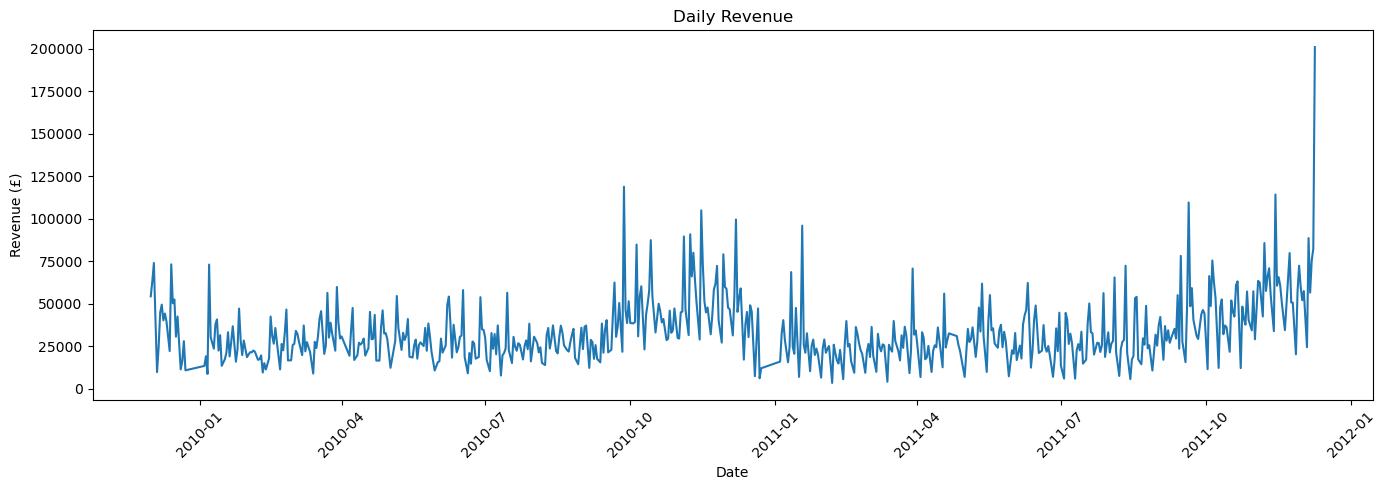

In [ ]:
## KPI Exploration

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_metrics["Date"],
    daily_metrics["Revenue"]
)

plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

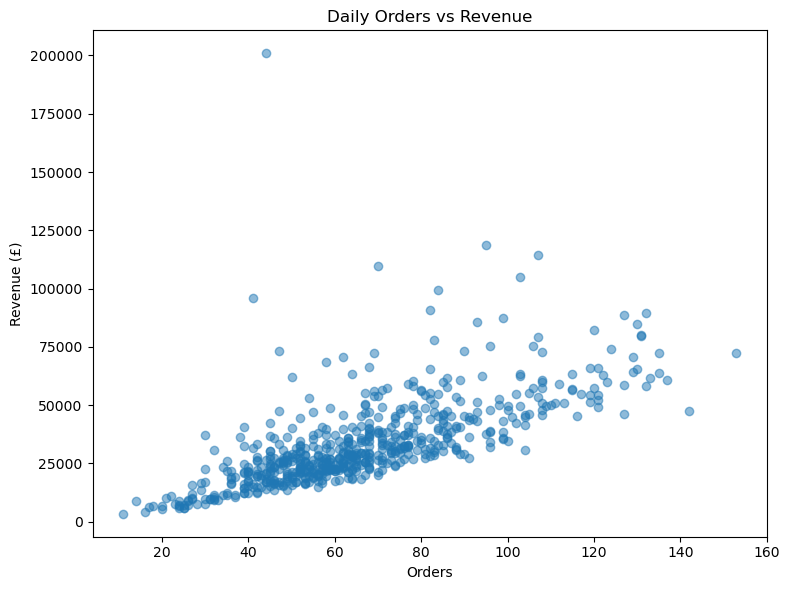

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    daily_metrics["Orders"],
    daily_metrics["Revenue"],
    alpha=0.5
)

plt.title("Daily Orders vs Revenue")
plt.xlabel("Orders")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

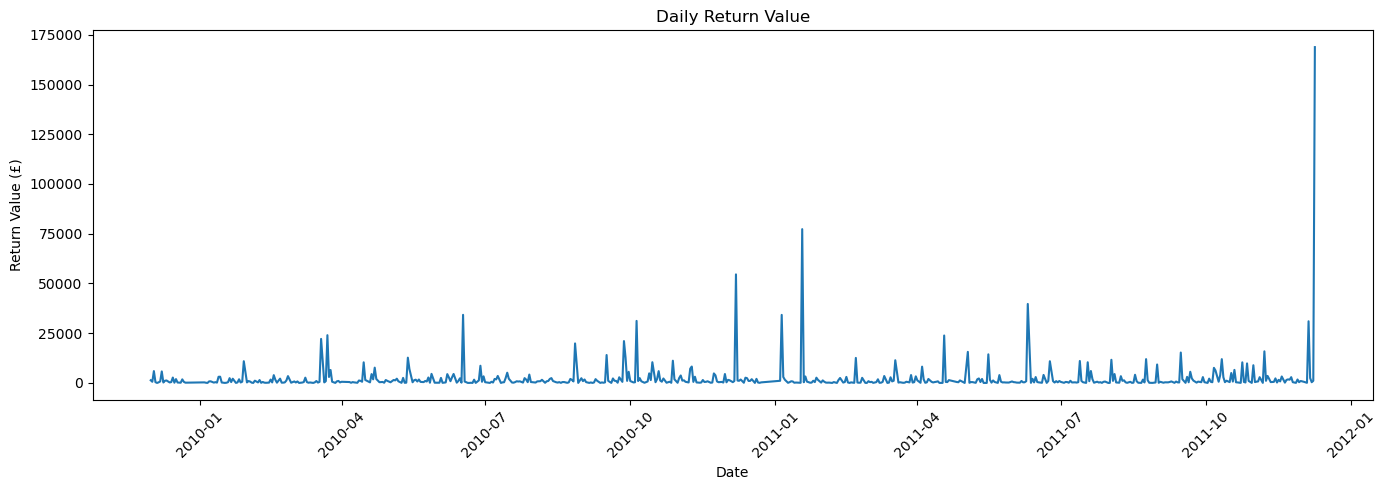

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_metrics["Date"],
    daily_metrics["ReturnValue"]
)

plt.title("Daily Return Value")
plt.xlabel("Date")
plt.ylabel("Return Value (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily_metrics.corr(numeric_only=True)["Revenue"].sort_values(
    ascending=False
)

Revenue              1.000000
UnitsSold            0.784259
AOV                  0.715334
Orders               0.678426
Customers            0.633274
ReturnValue          0.500699
CancellationCount    0.334149
ReturnedUnits        0.324757
Name: Revenue, dtype: float64

In [ ]:
### Weekday-Aware Baseline

daily_metrics["Date"] = pd.to_datetime(daily_metrics["Date"])

daily_metrics["DayOfWeek"] = daily_metrics["Date"].dt.day_name()

In [ ]:
daily_metrics["DayOfWeek"].value_counts()

DayOfWeek
Tuesday      104
Wednesday    104
Thursday     103
Friday        99
Sunday        99
Monday        94
Saturday       1
Name: count, dtype: int64

In [ ]:
daily_metrics["RevenueBaseline"] = (
    daily_metrics["Revenue"]
    .rolling(14)
    .mean()
    .shift(1)
)

In [ ]:
daily_metrics["RevenueDeviation"] = (
    (daily_metrics["Revenue"] - daily_metrics["RevenueBaseline"])
    / daily_metrics["RevenueBaseline"]
) * 100

In [ ]:
daily_metrics["RevenueStd"] = (
    daily_metrics["Revenue"]
    .rolling(14)
    .std()
    .shift(1)
)

In [ ]:
daily_metrics["RevenueZScore"] = (
    (daily_metrics["Revenue"] - daily_metrics["RevenueBaseline"])
    / daily_metrics["RevenueStd"]
)

In [ ]:
daily_metrics[
    ["Date", "Revenue", "RevenueBaseline",
     "RevenueDeviation", "RevenueZScore"]
].sort_values(
    "RevenueZScore",
    ascending=False
).head(10)

,Date,Revenue,RevenueBaseline,RevenueDeviation,RevenueZScore
603,2011-12-09,200918.980,59131.532143,239.783146,7.094220
276,2010-11-04,89585.630,38865.405714,130.502238,6.510167
243,2010-09-27,118838.470,32682.732929,263.612401,6.291606
57,2010-02-15,42469.531,18730.754500,126.736894,5.011238
530,2011-09-15,78151.970,32422.790714,141.040232,4.994205
391,2011-03-29,70711.920,24116.123571,193.214288,4.819161
534,2011-09-20,109553.900,34849.417143,214.363651,4.543118
331,2011-01-18,95947.730,26711.162143,259.204626,4.085811
408,2011-04-18,55983.990,22573.690071,148.005487,3.880845
581,2011-11-14,114237.400,53178.043571,114.820615,3.773876


In [ ]:
daily_metrics[
    ["Date", "Revenue", "RevenueBaseline",
     "RevenueDeviation", "RevenueZScore"]
].sort_values(
    "RevenueZScore"
).head(10)

,Date,Revenue,RevenueBaseline,RevenueDeviation,RevenueZScore
347,2011-02-06,3439.67,22220.278571,-84.520131,-2.708932
377,2011-03-13,4117.22,22588.684286,-81.773086,-2.536426
142,2010-05-30,10733.47,26975.950000,-60.210966,-2.205177
80,2010-03-14,8947.90,27056.952929,-66.929388,-2.184893
314,2010-12-19,7410.47,47353.390714,-84.350709,-2.143336
219,2010-08-29,14449.30,28024.953571,-48.441306,-2.142032
224,2010-09-05,12286.71,28574.545000,-57.001205,-2.125973
562,2011-10-23,12156.57,44327.026429,-72.575264,-2.116046
438,2011-05-29,7338.94,34025.183571,-78.430858,-2.081603
550,2011-10-09,12273.10,46372.718714,-73.533792,-2.043960


In [ ]:
daily_metrics["RevenueBaseline"] = (
    daily_metrics
    .groupby("DayOfWeek")["Revenue"]
    .transform(lambda x: x.rolling(8).mean().shift(1))
)

In [ ]:
daily_metrics["RevenueDeviation"] = (
    (daily_metrics["Revenue"] - daily_metrics["RevenueBaseline"])
    / daily_metrics["RevenueBaseline"]
) * 100

In [ ]:
daily_metrics["RevenueStd"] = (
    daily_metrics
    .groupby("DayOfWeek")["Revenue"]
    .transform(lambda x: x.rolling(8).std().shift(1))
)

daily_metrics["RevenueZScore"] = (
    (daily_metrics["Revenue"] - daily_metrics["RevenueBaseline"])
    / daily_metrics["RevenueStd"]
)

In [ ]:
daily_metrics[
    ["Date", "DayOfWeek", "Revenue",
     "RevenueBaseline", "RevenueDeviation", "RevenueZScore"]
].sort_values(
    "RevenueZScore",
    ascending=False
).head(10)

,Date,DayOfWeek,Revenue,RevenueBaseline,RevenueDeviation,RevenueZScore
603,2011-12-09,Friday,200918.98,52115.370000,285.527302,15.335728
243,2010-09-27,Monday,118838.47,29925.711250,297.111597,11.184775
534,2011-09-20,Tuesday,109553.90,29540.825125,270.855924,7.251452
391,2011-03-29,Tuesday,70711.92,28568.262500,147.519148,7.014841
506,2011-08-17,Wednesday,53284.76,26070.375000,104.388161,6.889253
238,2010-09-21,Tuesday,62499.11,29196.012500,114.067281,6.860751
448,2011-06-10,Friday,62234.44,27222.981375,128.609935,6.431234
383,2011-03-20,Sunday,21949.68,7353.901250,198.476676,5.287584
519,2011-09-02,Friday,42226.28,20777.558750,103.230228,5.276140
258,2010-10-14,Thursday,87417.94,39089.432625,123.635735,5.078887


In [ ]:
daily_metrics["RevenueAnomaly"] = (
    daily_metrics["RevenueZScore"].abs() >= 3
)

In [ ]:
daily_metrics["RevenueAnomaly"].value_counts()

RevenueAnomaly
False    571
True      33
Name: count, dtype: int64

In [ ]:
daily_metrics[
    daily_metrics["RevenueAnomaly"]
][
    ["Date", "DayOfWeek", "Revenue",
     "RevenueBaseline", "RevenueDeviation",
     "RevenueZScore"]
].sort_values(
    "RevenueZScore",
    ascending=False
).head(15)

,Date,DayOfWeek,Revenue,RevenueBaseline,RevenueDeviation,RevenueZScore
603,2011-12-09,Friday,200918.98,52115.370000,285.527302,15.335728
243,2010-09-27,Monday,118838.47,29925.711250,297.111597,11.184775
534,2011-09-20,Tuesday,109553.90,29540.825125,270.855924,7.251452
391,2011-03-29,Tuesday,70711.92,28568.262500,147.519148,7.014841
506,2011-08-17,Wednesday,53284.76,26070.375000,104.388161,6.889253
238,2010-09-21,Tuesday,62499.11,29196.012500,114.067281,6.860751
448,2011-06-10,Friday,62234.44,27222.981375,128.609935,6.431234
383,2011-03-20,Sunday,21949.68,7353.901250,198.476676,5.287584
519,2011-09-02,Friday,42226.28,20777.558750,103.230228,5.276140
258,2010-10-14,Thursday,87417.94,39089.432625,123.635735,5.078887


In [ ]:
## Anomaly Context

anomalies = daily_metrics[
    daily_metrics["RevenueAnomaly"]
][
    [
        "Date",
        "DayOfWeek",
        "Revenue",
        "RevenueBaseline",
        "RevenueDeviation",
        "RevenueZScore",
        "Orders",
        "Customers",
        "UnitsSold",
        "AOV",
        "ReturnedUnits",
        "ReturnValue",
        "CancellationCount"
    ]
].sort_values("RevenueZScore", ascending=False)

anomalies.head(10)

,Date,DayOfWeek,Revenue,RevenueBaseline,RevenueDeviation,RevenueZScore,Orders,Customers,UnitsSold,AOV,ReturnedUnits,ReturnValue,CancellationCount
603,2011-12-09,Friday,200918.98,52115.370000,285.527302,15.335728,44,35,93950,4566.340455,81030.0,168789.07,5.0
243,2010-09-27,Monday,118838.47,29925.711250,297.111597,11.184775,95,69,125489,1250.931263,2756.0,21033.77,15.0
534,2011-09-20,Tuesday,109553.90,29540.825125,270.855924,7.251452,70,53,43683,1565.055714,31.0,325.82,6.0
391,2011-03-29,Tuesday,70711.92,28568.262500,147.519148,7.014841,62,46,32803,1140.514839,59.0,180.45,8.0
506,2011-08-17,Wednesday,53284.76,26070.375000,104.388161,6.889253,54,45,25649,986.754815,2148.0,4107.74,9.0
238,2010-09-21,Tuesday,62499.11,29196.012500,114.067281,6.860751,103,76,37072,606.787476,585.0,1080.50,33.0
448,2011-06-10,Friday,62234.44,27222.981375,128.609935,6.431234,50,41,10669,1244.688800,334.0,39693.78,13.0
383,2011-03-20,Sunday,21949.68,7353.901250,198.476676,5.287584,60,56,14038,365.828000,30.0,172.85,4.0
519,2011-09-02,Friday,42226.28,20777.558750,103.230228,5.276140,74,58,18433,570.625405,125.0,576.95,14.0
258,2010-10-14,Thursday,87417.94,39089.432625,123.635735,5.078887,99,81,37123,883.009495,513.0,1448.76,17.0


In [ ]:
def create_anomaly_context(row):
    return {
        "date": str(row["Date"].date()),
        "day": row["DayOfWeek"],
        "revenue": round(row["Revenue"], 2),
        "baseline_revenue": round(row["RevenueBaseline"], 2),
        "revenue_deviation_pct": round(row["RevenueDeviation"], 2),
        "revenue_zscore": round(row["RevenueZScore"], 2),
        "orders": int(row["Orders"]),
        "customers": int(row["Customers"]),
        "units_sold": int(row["UnitsSold"]),
        "aov": round(row["AOV"], 2),
        "returned_units": int(row["ReturnedUnits"]),
        "return_value": round(row["ReturnValue"], 2),
        "cancellations": int(row["CancellationCount"])
    }

In [ ]:
context = create_anomaly_context(anomalies.iloc[2])

context

{'date': '2011-09-20',
 'day': 'Tuesday',
 'revenue': np.float64(109553.9),
 'baseline_revenue': np.float64(29540.83),
 'revenue_deviation_pct': np.float64(270.86),
 'revenue_zscore': np.float64(7.25),
 'orders': 70,
 'customers': 53,
 'units_sold': 43683,
 'aov': np.float64(1565.06),
 'returned_units': 31,
 'return_value': np.float64(325.82),
 'cancellations': 6}

In [ ]:
def create_anomaly_context(row):
    return {
        "date": str(row["Date"].date()),
        "day": row["DayOfWeek"],
        "revenue": float(round(row["Revenue"], 2)),
        "baseline_revenue": float(round(row["RevenueBaseline"], 2)),
        "revenue_deviation_pct": float(round(row["RevenueDeviation"], 2)),
        "revenue_zscore": float(round(row["RevenueZScore"], 2)),
        "orders": int(row["Orders"]),
        "customers": int(row["Customers"]),
        "units_sold": int(row["UnitsSold"]),
        "aov": float(round(row["AOV"], 2)),
        "returned_units": int(row["ReturnedUnits"]),
        "return_value": float(round(row["ReturnValue"], 2)),
        "cancellations": int(row["CancellationCount"])
    }

In [ ]:
context = create_anomaly_context(anomalies.iloc[2])

context

{'date': '2011-09-20',
 'day': 'Tuesday',
 'revenue': 109553.9,
 'baseline_revenue': 29540.83,
 'revenue_deviation_pct': 270.86,
 'revenue_zscore': 7.25,
 'orders': 70,
 'customers': 53,
 'units_sold': 43683,
 'aov': 1565.06,
 'returned_units': 31,
 'return_value': 325.82,
 'cancellations': 6}

In [ ]:
import json

prompt = f"""
You are a business analytics assistant.

Analyze the following detected revenue anomaly.

Anomaly data:
{json.dumps(context, indent=2)}

Your task:
1. Briefly explain what happened.
2. Identify the metrics that best explain the anomaly.
3. State whether the anomaly appears primarily driven by orders, units sold,
   average order value, or another metric.
4. Mention anything unusual about returns or cancellations.
5. Suggest 1-2 things a business analyst should investigate.

Do not invent causes that are not supported by the data.
Clearly distinguish observed facts from possible explanations.
Keep the response concise and business-focused.
"""

print(prompt)


You are a business analytics assistant.

Analyze the following detected revenue anomaly.

Anomaly data:
{
  "date": "2011-09-20",
  "day": "Tuesday",
  "revenue": 109553.9,
  "baseline_revenue": 29540.83,
  "revenue_deviation_pct": 270.86,
  "revenue_zscore": 7.25,
  "orders": 70,
  "customers": 53,
  "units_sold": 43683,
  "aov": 1565.06,
  "returned_units": 31,
  "return_value": 325.82,
  "cancellations": 6
}

Your task:
1. Briefly explain what happened.
2. Identify the metrics that best explain the anomaly.
3. State whether the anomaly appears primarily driven by orders, units sold,
   average order value, or another metric.
4. Mention anything unusual about returns or cancellations.
5. Suggest 1-2 things a business analyst should investigate.

Do not invent causes that are not supported by the data.
Clearly distinguish observed facts from possible explanations.
Keep the response concise and business-focused.

